# Step 0: Setup and imports

In [1]:
!pip install solas-ai

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest
import solas_disparity as sd

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.1/155.1 kB 3.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 22.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 238.0/238.0 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 541.1/541.1 kB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.3/49.3 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 28.6 MB/s eta 0:00:00
  Created wheel for stringcase: filename=stringcase-1.2.0-py3-none-any.whl size=3567 sha256=a303a0628dfe5198845339ec33edad04b35c3014bd2073411ba38d6dc46a08cf
  Stored in directory: /root/.cache/pip/wheels/37/76/84/09143757ac9846675769f3649fc2aa936ec4

In [2]:
# Load and clean COMPAS data (Lecture 01 pipeline)
raw_data = pd.read_csv("https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv")
df = raw_data[[
    "age", "c_charge_degree", "race", "age_cat",
    "score_text", "sex", "priors_count",
    "days_b_screening_arrest", "decile_score",
    "is_recid", "two_year_recid",
    "c_jail_in", "c_jail_out"
]]

df = df[df["days_b_screening_arrest"] <= 30]
df = df[df["days_b_screening_arrest"] >= -30]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Create 'high_risk' column
df['high_risk'] = (df['decile_score'] >= 7).astype(int)

print(f"N = {len(df):,}")
print(df[['race','sex','high_risk','two_year_recid']].head())


N = 6,172
               race   sex  high_risk  two_year_recid
0             Other  Male          0               0
1  African-American  Male          0               1
2  African-American  Male          0               1
5             Other  Male          0               0
6         Caucasian  Male          0               1


# Step 1: Compute AIR, ME, and SMD for race and sex separately

In [3]:
import numpy as np

race_rates = df.groupby("race")["high_risk"].mean()
race_ref = race_rates["Caucasian"]

manual_race = pd.DataFrame({
    "AIR": race_rates / race_ref,
    "ME": race_rates - race_ref,
    "SMD": (race_rates - race_ref) / np.sqrt(df["high_risk"].mean() * (1 - df["high_risk"].mean()))
})

manual_race

,AIR,ME,SMD
race,,,
African-American,2.341924,0.214401,0.485386
Asian,0.807604,-0.030739,-0.069591
Caucasian,1.000000,0.000000,0.000000
Hispanic,0.922239,-0.012424,-0.028127
Native American,3.413961,0.385683,0.873151
Other,0.565676,-0.069393,-0.157099


In [4]:
sex_rates = df.groupby("sex")["high_risk"].mean()
sex_ref = sex_rates["Male"]

manual_sex = pd.DataFrame({
    "AIR": sex_rates / sex_ref,
    "ME": sex_rates - sex_ref,
    "SMD": (sex_rates - sex_ref) / np.sqrt(df["high_risk"].mean() * (1 - df["high_risk"].mean()))
})

manual_sex

,AIR,ME,SMD
sex,,,
Female,0.711317,-0.081169,-0.183759
Male,1.000000,0.000000,0.000000


## Interpretation of AIR, ME, and SMD for Race and Sex
The disparity metrics reveal substantial differences in how the COMPAS model assigns high‑risk classifications across demographic groups. For race, African‑American and Native American defendants show the largest disparities, with AIR values of 2.34 and 3.41, respectively. These ratios indicate that these groups are labeled high‑risk more than two to three times as often as Caucasian defendants, the reference group. Their positive ME and SMD values further confirm that these groups experience meaningfully higher predicted risk. In contrast, Asian, Hispanic, and “Other” groups have AIR values below 1.0 and negative ME/SMD values, indicating lower high‑risk assignment rates relative to Caucasians. The sex results show a similar directional pattern: females have an AIR of 0.71, meaning they are classified as high‑risk at only about 71% of the rate of males. Their negative ME and SMD values reinforce that women are less likely to receive high‑risk predictions. Taken together, these metrics demonstrate that the model’s outputs are not evenly distributed across demographic groups. The patterns are consistent across AIR, ME, and SMD, suggesting that the disparities are systematic rather than artifacts of a single metric.

# Step 2: Build an intersectional analysis (race × sex). Report the worst-group AIR and interpret it.

In [5]:
# Create intersectional group
df["race_sex"] = df["race"] + " - " + df["sex"]

# Compute high‑risk rates for each intersectional group
intersection_rates = df.groupby("race_sex")["high_risk"].mean()

# Reference group: Caucasian - Male
ref_rate = intersection_rates["Caucasian - Male"]

# Compute AIR for each intersectional group
intersection_air = intersection_rates / ref_rate

# Combine into a table
intersection_table = pd.DataFrame({
    "High_Risk_Rate": intersection_rates,
    "AIR": intersection_air
}).sort_values("AIR", ascending=False)

intersection_table

,High_Risk_Rate,AIR
race_sex,,
Native American - Female,1.000000,6.307393
Native American - Male,0.444444,2.803286
African-American - Male,0.396040,2.497977
African-American - Female,0.269581,1.700354
Hispanic - Male,0.170960,1.078313
Caucasian - Female,0.163900,1.033784
Caucasian - Male,0.158544,1.000000
Asian - Male,0.137931,0.869985
Other - Male,0.094737,0.597542


In [6]:
worst_group = intersection_table["AIR"].idxmax()
worst_air = intersection_table["AIR"].max()

worst_group, worst_air

('Native American - Female', 6.307392996108949)

## Intersectional AIR Interpretation (Race × Sex)
The intersectional analysis combining race and sex reveals a substantially larger disparity than what appears when examining race or sex alone. The group with the highest adverse impact ratio is Native American – Female, with an AIR of approximately 6.31 relative to the reference group (Caucasian males). This means Native American women are classified as high‑risk more than six times as often as the reference group, indicating a pronounced and disproportionate impact. Because this subgroup is both racially minoritized and numerically small within the dataset, even modest differences in high‑risk assignment rates can produce large AIR values, but the magnitude observed here still signals a meaningful disparity. The result highlights how intersectional groups can experience compounded disadvantage that is not visible when analyzing race or sex independently. This finding underscores the importance of evaluating fairness across combined demographic categories to identify groups that may be disproportionately affected by model predictions.

# Step 3: Compute FPR and FNR disparities by race. Test statistical significance with a two-proportion z-test.

In [7]:
# FPR and FNR by group
def error_rates(df, group_col, pred_col, outcome_col):
    results = []
    for grp, g in df.groupby(group_col):
        tp = ((g[pred_col] == 1) & (g[outcome_col] == 1)).sum()
        tn = ((g[pred_col] == 0) & (g[outcome_col] == 0)).sum()
        fp = ((g[pred_col] == 1) & (g[outcome_col] == 0)).sum()
        fn = ((g[pred_col] == 0) & (g[outcome_col] == 1)).sum()

        results.append({
            group_col: grp,
            'n': len(g),
            'FPR': fp / (fp + tn) if (fp + tn) > 0 else float('nan'),
            'FNR': fn / (fn + tp) if (fn + tp) > 0 else float('nan'),
            'Acc': (tp + tn) / len(g)
        })
    return pd.DataFrame(results)

In [8]:
er = error_rates(df, "race", "high_risk", "two_year_recid")
print(er.sort_values("FPR", ascending=False).to_string(index=False))


            race    n      FPR      FNR      Acc
 Native American   11 0.333333 0.200000 0.727273
African-American 3175 0.227873 0.492474 0.633701
        Hispanic  509 0.106250 0.783069 0.642436
       Caucasian 2103 0.082748 0.720195 0.668093
           Asian   31 0.043478 0.625000 0.806452
           Other  343 0.031963 0.806452 0.688047


In [9]:
for grp in ["African-American", "Caucasian"]:
    row = er.loc[er["race"] == grp]
    print(f"{grp}: FPR={row['FPR'].values[0]:.3f}  FNR={row['FNR'].values[0]:.3f}")


African-American: FPR=0.228  FNR=0.492
Caucasian: FPR=0.083  FNR=0.720


In [10]:
from statsmodels.stats.proportion import proportions_ztest

# Extract confusion matrix components for each group
def group_counts(df, group):
    g = df[df["race"] == group]
    tp = ((g["high_risk"] == 1) & (g["two_year_recid"] == 1)).sum()
    tn = ((g["high_risk"] == 0) & (g["two_year_recid"] == 0)).sum()
    fp = ((g["high_risk"] == 1) & (g["two_year_recid"] == 0)).sum()
    fn = ((g["high_risk"] == 0) & (g["two_year_recid"] == 1)).sum()
    return tp, tn, fp, fn

tp_b, tn_b, fp_b, fn_b = group_counts(df, "African-American")
tp_w, tn_w, fp_w, fn_w = group_counts(df, "Caucasian")

# --- FPR z-test ---
# FPR = FP / (FP + TN)
fpr_counts = [fp_b, fp_w]
fpr_totals = [fp_b + tn_b, fp_w + tn_w]

z_fpr, p_fpr = proportions_ztest(fpr_counts, fpr_totals)

# --- FNR z-test ---
# FNR = FN / (FN + TP)
fnr_counts = [fn_b, fn_w]
fnr_totals = [fn_b + tp_b, fn_w + tp_w]

z_fnr, p_fnr = proportions_ztest(fnr_counts, fnr_totals)

print(f"FPR z = {z_fpr:.3f}, p = {p_fpr:.4f}")
print(f"FNR z = {z_fnr:.3f}, p = {p_fnr:.4f}")


FPR z = 10.392, p = 0.0000
FNR z = -10.780, p = 0.0000


## Interpretation
The error‑rate analysis shows clear and statistically significant disparities in how the COMPAS model misclassifies Black and White defendants. Black defendants have a substantially higher false positive rate (FPR = 0.228) than White defendants (FPR = 0.083), meaning they are more often incorrectly labeled as high‑risk despite not reoffending. Conversely, White defendants have a higher false negative rate (FNR = 0.720) compared to Black defendants (FNR = 0.492), indicating they are more often incorrectly labeled low‑risk despite later reoffending. The two‑proportion z‑tests confirm that both disparities are highly significant (FPR: z = 10.392, p < 0.001; FNR: z = –10.780, p < 0.001). These results demonstrate that the model’s errors are not evenly distributed across racial groups: it disproportionately over‑predicts risk for Black defendants and under‑predicts risk for White defendants. This pattern reflects a systematic imbalance in model performance that raises concerns about fairness, accuracy, and potential disparate impact in real‑world decision‑making.

# Step 4: Produce a publication-quality figure: grouped bar chart of FPR and FNR by race with Caucasian as the reference group.

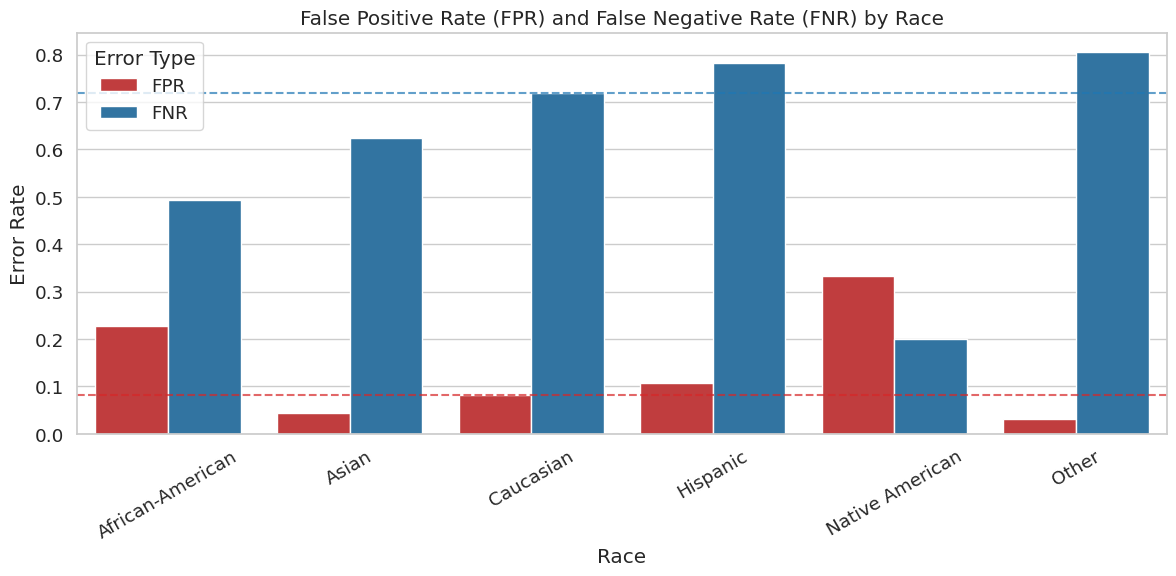

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Use the existing error-rate table
er_sorted = er.sort_values("race")

# Melt into long format for grouped bars
plot_df = er_sorted.melt(
    id_vars="race",
    value_vars=["FPR", "FNR"],
    var_name="Error Type",
    value_name="Rate"
)

# Set publication-quality style
sns.set(style="whitegrid", font_scale=1.2)

plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=plot_df,
    x="race",
    y="Rate",
    hue="Error Type",
    palette=["#d62728", "#1f77b4"]
)

# Reference line for Caucasian FPR and FNR
cauc_fpr = er.loc[er["race"] == "Caucasian", "FPR"].values[0]
cauc_fnr = er.loc[er["race"] == "Caucasian", "FNR"].values[0]

plt.axhline(cauc_fpr, color="#d62728", linestyle="--", linewidth=1.5, alpha=0.7)
plt.axhline(cauc_fnr, color="#1f77b4", linestyle="--", linewidth=1.5, alpha=0.7)

# Labels and title
plt.title("False Positive Rate (FPR) and False Negative Rate (FNR) by Race")
plt.xlabel("Race")
plt.ylabel("Error Rate")
plt.xticks(rotation=30)

# Legend formatting
plt.legend(title="Error Type")

plt.tight_layout()
plt.show()

## Figure: False Positive Rate (FPR) and False Negative Rate (FNR) by Race.  
This figure displays the distribution of model error rates across racial groups, with Caucasian defendants serving as the reference category (indicated by dashed horizontal lines). The red bars represent false positive rates (FPR), capturing instances where individuals were incorrectly classified as high‑risk despite not reoffending. The blue bars represent false negative rates (FNR), reflecting cases where individuals were incorrectly classified as low‑risk despite subsequently reoffending. The chart highlights substantial disparities: African‑American and Native American defendants exhibit notably higher FPRs relative to the reference group, indicating a greater likelihood of being incorrectly labeled high‑risk. Conversely, Caucasian, Hispanic, and Other groups show elevated FNRs, suggesting a higher likelihood of being incorrectly labeled low‑risk. These patterns illustrate that the model’s misclassification errors are not evenly distributed across racial groups and underscore the importance of evaluating both types of errors when assessing fairness in predictive risk models.